In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
clientes = pd.read_csv('/content/datos_2.csv')
clientes.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [4]:
clientes.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [6]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


##**Remover columnas irrelevantes**

In [7]:
clientes = clientes.drop(columns=['CustomerID'])

In [8]:
clientes.sample(2)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
102,No,Male,No,Yes,Yes,62,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,3.60,108.15,6825.65
2157,No,Female,No,No,No,1,Yes,No,No,No,...,No,No,No,No,Month-to-month,No,Credit card (automatic),0.68,20.30,20.30


In [10]:
columnas_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for columna in columnas_fix:
    clientes[columna] = clientes[columna].replace({'No internet service': 'No'})

In [11]:
clientes.head(2)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.3
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.4


##**Correlación entre variables numericas**

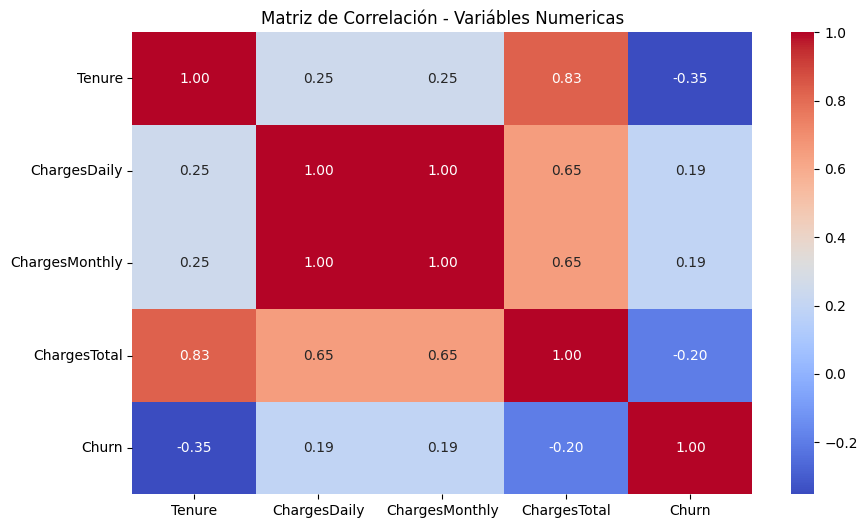

In [14]:
clientes_numerico = clientes.select_dtypes(include=["int64", "float64"])

clientes_numerico["Churn"] = clientes["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = clientes_numerico.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()


In [15]:
clientes = clientes.drop(columns=["ChargesDaily","ChargesTotal"])

In [17]:
clientes.head(2)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9


##**proporción por categoria**

In [18]:
columna_categorica = clientes.select_dtypes(include=["object"]).columns
columna_categorica = columna_categorica.drop("Churn")

In [23]:
for col in columna_categorica:
    print(f"\nAnalisis de variable: {col}")
    display(pd.crosstab(clientes[col], clientes["Churn"], normalize="index") * 100)


Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [26]:
from sklearn.preprocessing import LabelEncoder

# 1. Identificar qué columnas siguen siendo texto (objetos)
categorical_cols = clientes.select_dtypes(include=['object']).columns

# 2. Convertirlas todas a números
le = LabelEncoder()
for col in categorical_cols:
    clientes[col] = le.fit_transform(clientes[col])

# 3. Ahora sí, define tu X y entrena el árbol
X = clientes.drop("Churn", axis=1)
y = clientes["Churn"]

In [29]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# 1. Preparar los datos (usando la copia df_rank que ya tiene Label Encoding)
# Asegúrate de que X no contenga la variable objetivo 'Churn'

# 2. Entrenar el modelo de Árbol de Decisión
# Usamos un random_state para que los resultados sean siempre iguales
clf = DecisionTreeClassifier(random_state=42, max_depth=10)
clf.fit(X, y)

# 3. Extraer la importancia de las variables (Feature Importance)
importances = clf.feature_importances_

# 4. Crear un DataFrame con el ranking
tree_rank = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": importances
})

# 5. Ordenar de mayor a menor importancia
tree_rank = tree_rank.sort_values(by="Importancia", ascending=False)

tree_rank

,Variable,Importancia
14,Contract,0.329485
17,ChargesMonthly,0.251210
4,Tenure,0.216104
16,PaymentMethod,0.028796
7,InternetService,0.025012
11,TechSupport,0.019454
2,Partner,0.015984
15,PaperlessBilling,0.015627
1,SeniorCitizen,0.014168
3,Dependents,0.012453


In [30]:
from sklearn.model_selection import train_test_split

# Dividimos los datos: 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos totales: {len(X)}")
print(f"Entrenamiento: {len(X_train)}")
print(f"Prueba: {len(X_test)}")

Datos totales: 7043
Entrenamiento: 5634
Prueba: 1409


##**Entrenamiento**

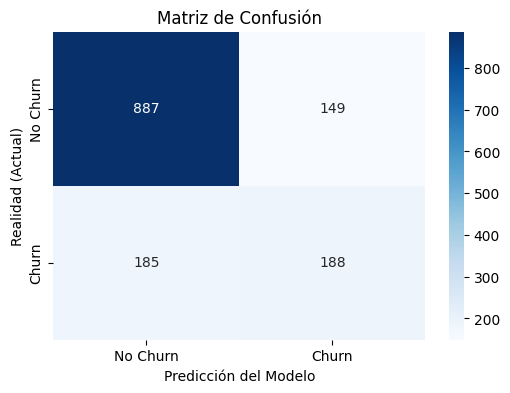

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1036
           1       0.56      0.50      0.53       373

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.69      1409
weighted avg       0.76      0.76      0.76      1409



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Entrenar el modelo con los datos estratificados
clf.fit(X_train, y_train)

# 2. Predecir
y_pred = clf.predict(X_test)

# 3. Crear la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

# 4. Graficarla para que sea legible
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Actual)')
plt.title('Matriz de Confusión')
plt.show()

# 5. Ver el reporte detallado
print(classification_report(y_test, y_pred))

##**Evaluación**

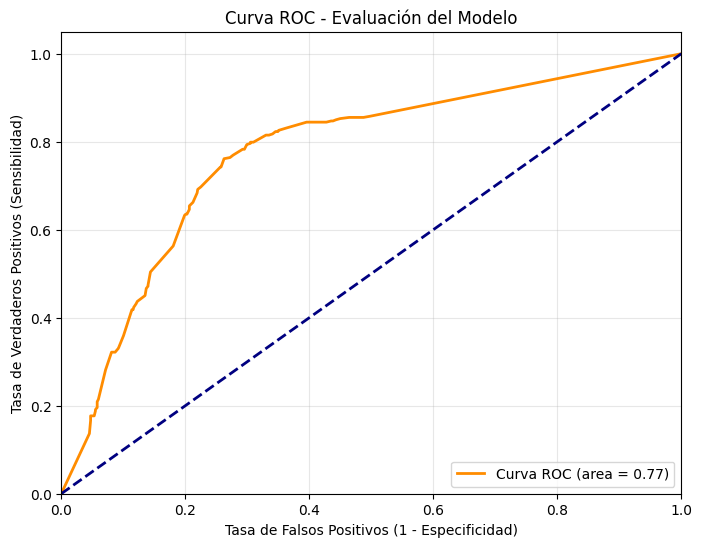

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

# 1. Obtener las probabilidades (necesario para la curva ROC)
# El modelo no solo dice "Sí/No", nos da la probabilidad de que sea "Sí"
y_probs = clf.predict_proba(X_test)[:, 1]

# 2. Calcular el Score AUC
auc_value = roc_auc_score(y_test, y_probs)

# 3. Graficar la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (area = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea de azar
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Evaluación del Modelo')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

##**Random forest**

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Creamos el modelo
# n_estimators=100 significa que usaremos 100 árboles diferentes
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Entrenamos con los datos de entrenamiento
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

##**Evaluando el modelo**

<Figure size 800x600 with 0 Axes>

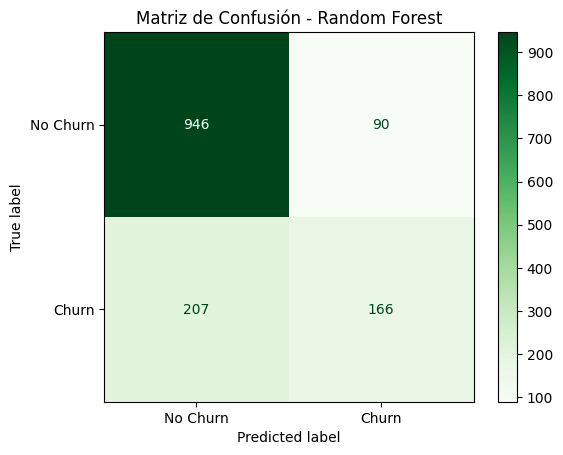

--- REPORTE DE CLASIFICACIÓN RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1036
           1       0.65      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [35]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Realizamos las predicciones
y_pred_rf = rf_model.predict(X_test)

# Mostramos la Matriz de Confusión de forma visual
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Greens', display_labels=['No Churn', 'Churn'])
plt.title("Matriz de Confusión - Random Forest")
plt.show()

# Imprimimos el reporte de métricas
print("--- REPORTE DE CLASIFICACIÓN RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

# 📑 Informe Ejecutivo: Análisis de Churn y Modelado Predictivo
**Proyecto:** Retención de Clientes en Telecomunicaciones  
**Autor:** Gestión de Control / Data Analysis Team

---

## 1. Resumen del Proyecto
Este análisis busca identificar los factores críticos que influyen en la cancelación de servicios (*Churn*). Se procesó un conjunto de datos con información sociodemográfica, servicios contratados y métricas financieras para construir un sistema de alerta temprana basado en Machine Learning.

---

## 2. Factores Críticos de Cancelación
Tras realizar pruebas estadísticas de **Chi-cuadrado ($\chi^2$)** y analizar la importancia de variables en modelos de ensamble, se determinaron los siguientes hallazgos:

### 🔑 Variables de Mayor Impacto
1. **Tipo de Contrato:** Los clientes con contratos **Month-to-month** representan el segmento de mayor riesgo. La estabilidad aumenta drásticamente en contratos de 1 y 2 años.
2. **Antigüedad (Tenure):** Existe una relación inversa. Los clientes en sus primeros **6 meses** tienen una tasa de fuga significativamente superior.
3. **Método de Pago:** El uso de **Electronic Check** está fuertemente correlacionado con el abandono, a diferencia de los métodos automáticos (Credit Card/Bank Transfer).
4. **Cargos Mensuales:** Los clientes con cargos elevados sin servicios de valor agregado (como protección de dispositivo o soporte técnico) tienden a desertar más rápido.



---

## 3. Metodología y Limpieza de Datos
* **Normalización:** Se consolidaron categorías redundantes (ej. "No internet service" se unificó con "No").
* **Codificación:** Se utilizó `LabelEncoder` para transformar variables categóricas en formatos procesables por los modelos.
* **Balanceo:** Se empleó la técnica de **estratificación** en la división de datos (`stratify=y`) para asegurar que la proporción de fugas fuera constante en entrenamiento y prueba.

---

## 4. Evaluación de Modelos
Se compararon tres arquitecturas distintas para determinar la mejor capacidad predictiva:

| Modelo | Ventajas